In [180]:
import math
import numpy as np
import pandas as pd
import yfinance as yf
from arch import arch_model
from scipy.stats import norm
from scipy import stats, optimize
from datetime import datetime, timedelta

In [181]:
def option_europ_bs(op_type: str, S: float, K: float, T: float, r: float, sigma: float, div: float = 0.0):
    """Option price with Black-Scholes model
    Args:
        - op_type: option type
        - S: spot price
        - K: strike price
        - T: time to maturity
        - r: risk-free rate
        - sigma: volatility
        - div: dividend rate
    Returns:
        - option price
    """
    d1 = (np.log(S / K) + (r - div + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if op_type.upper() == "C":  # Call
        precio_BS = S * np.exp(-div * T) * stats.norm.cdf(d1) - K * np.exp(-r * T) * stats.norm.cdf(d2)
    elif op_type.upper() == "P":  # Put
        precio_BS = K * np.exp(-r * T) * stats.norm.cdf(-d2) - S * np.exp(-div * T) * stats.norm.cdf(-d1)
    else:
        raise ValueError("Option type must be 'C' for Call or 'P' for Put")
    
    return precio_BS

#------------------------------------------------

def implied_volatility(S, K, T, r, market_price, op_type="C"):
    """Implied volatility
    Args:
        - S: spot price
        - K: strike price
        - T: time to maturity
        - r: risk-free rate
        - market_price: market price of the option
        - op_type: option type
    Returns:
        - implied volatility
    """
    def error_function(sigma):
        return option_europ_bs(op_type, S, K, T, r, sigma) - market_price

    result = optimize.root_scalar(error_function, bracket=[0.01, 2.0], method='bisect')
    return result.root if result.converged else np.nan

#------------------------------------------------

def get_data(ticker, start_date, end_date):
    """Get historical data from Yahoo Finance
    Args:
        - ticker: ticker of the stock
        - start_date: start date of the historical data
        - end_date: end date of the historical data
    Returns:
        - df: DataFrame with the historical data
    """
    stock = yf.Ticker(ticker)
    hist = stock.history(start=start_date, end=end_date)
    df = pd.DataFrame(hist, columns=['Close'])
    return df

#------------------------------------------------

def train_garch(ticker, start_date, end_date, p:int=1, q:int=1):
    """Train GARCH model
    Args:
        - ticker: ticker of the stock
        - start_date: start date of the historical data
        - end_date: end date of the historical data
    Returns:
        - res_garch: GARCH model results
        - df: DataFrame with the historical data
    """
    df = get_data(ticker, start_date, end_date)

    df['log_return'] = np.log(df['Close']).diff()  #* 100
    df.dropna(inplace=True)

    garch_mod = arch_model(df['log_return'], mean="Zero", vol="Garch", p=p, q=q, dist="t", rescale=False)
    res_garch = garch_mod.fit(disp="off")
    
    return res_garch, df

#------------------------------------------------

def garch_forecast(res_garch, horizon=30):
    """Forecast of future volatility with GARCH
    Args:
        - res_garch: GARCH model results
        - horizon: number of days to forecast
    Returns:
        - forecast: GARCH forecast results
    """
    forecast = res_garch.forecast(horizon=horizon)
    return forecast

#------------------------------------------------

def get_next_expiration(date, n_days, expirations):
    """
    Fetch the expiration date N days ahead from a particular date.
    
    Args:
        date (datetime.date): The starting date.
        n_days (int): Number of days to look ahead.
        expirations (list): List of available expiration dates as strings (YYYY-MM-DD).
    
    Returns:
        str: The closest expiration date after n_days, in YYYY-MM-DD format.
    """
    target_date = date + timedelta(days=n_days)

    expiration_dates = [datetime.strptime(exp, '%Y-%m-%d').date() for exp in expirations]
    
    future_dates = [d for d in expiration_dates if d >= target_date]
    
    if not future_dates:
        return None
    
    closest_date = min(future_dates, key=lambda d: abs(d - target_date))
    
    return closest_date.strftime('%Y-%m-%d')

#------------------------------------------------

def atm_option(calls, puts, S):
    """Get the at-the-money option based on the closest strike to the spot price S."""
    atm_call = calls.iloc[(calls['strike'] - S).abs().idxmin()]
    atm_put = puts.iloc[(puts['strike'] - S).abs().idxmin()]
    
    return atm_call, atm_put

Compare

In [182]:
start_date = '2022-01-04'
end_date   = '2024-10-22'
ticker     = 'SPY'
periods    = 30

res_garch, df = train_garch(ticker = ticker, start_date = start_date, end_date = end_date)

vol_forecast = garch_forecast(res_garch, horizon=60)
vol_forecast.variance.values

predicted_volatility = np.sqrt(vol_forecast.variance.values[-1, :])

In [183]:
stock = yf.Ticker(ticker)
expirations = stock.options

today = datetime.now().date()
expirations = stock.options

expiration = get_next_expiration(today, 30, expirations)

In [184]:
options_chain = stock.option_chain(expiration)

# Opciones
calls = options_chain.calls
puts  = options_chain.puts

In [185]:
# Call
S = df.Close.iloc[-1].item()
T = periods / 360
r = 0.0256

# Get atm option
atm_call, atm_put = atm_option(calls, puts, S)

K = atm_call.strike.item()
market_price = atm_call.lastPrice.item()

imp_vol = implied_volatility(S, K, T, r, market_price)
imp_vol

0.16628672468493275

In [186]:
# Put
S = df.Close.iloc[-1].item()
T = periods / 360
r = 0.0256

# Get atm option
atm_call, atm_put = atm_option(calls, puts, S)

K = atm_put.strike.item()
market_price = atm_put.lastPrice.item()

imp_vol = implied_volatility(S, K, T, r, market_price, op_type="P")
imp_vol

0.14444963189892404

In [187]:
op_type = "P"

results = []

for period in range(1, periods):
    expiration = get_next_expiration(today, period, expirations)
    options_chain = stock.option_chain(expiration)

    # Opciones CALL
    calls = options_chain.calls
    puts  = options_chain.puts

    S = df.Close.iloc[-1].item()
    T = periods / 360
    r = 0.0256

    # Get atm option
    atm_call, atm_put = atm_option(calls, puts, S)

    if op_type == "C":
        K = atm_call.strike.item()
        market_price = atm_call.lastPrice.item()
    else:
        K = atm_put.strike.item()
        market_price = atm_put.lastPrice.item()

    imp_vol = implied_volatility(S, K, T, r, market_price, op_type=op_type)
    pred_vol = predicted_volatility[period -1].item()

    date = date.today() + pd.Timedelta(days=period)

    results.append([date, imp_vol, pred_vol])

results = pd.DataFrame(results, columns=['date', 'imp_vol', 'pred_vol'])

historical_vol = df['log_return'].std() * np.sqrt(360)

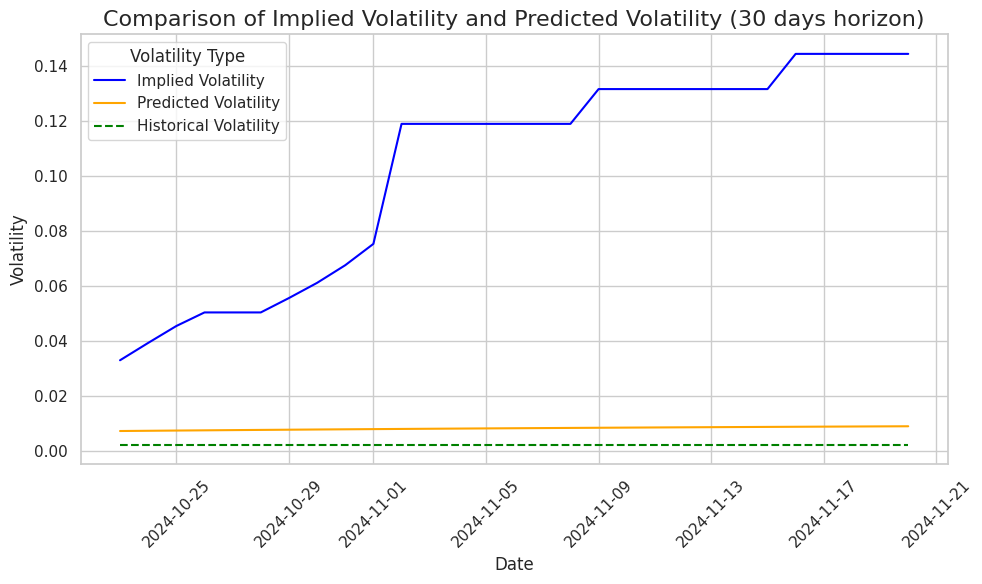

In [190]:
import seaborn as sns
import matplotlib.pyplot as plt

historical_vol = (df['log_return'].std() * np.sqrt(360)) / 100

results['historical_vol'] = historical_vol

sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.lineplot(data=results, x='date', y='imp_vol', label='Implied Volatility', color='blue')
sns.lineplot(data=results, x='date', y='pred_vol', label='Predicted Volatility', color='orange')
sns.lineplot(data=results, x='date', y='historical_vol', label='Historical Volatility', color='green', linestyle='--')

plt.title(f'Comparison of Implied Volatility and Predicted Volatility ({periods} days horizon)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Volatility', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Volatility Type')
plt.tight_layout()
plt.show()
